# Reviive — Clasificador de producto recomendado

**Modulo:** Machine Learning (sección 15.1 del *Documento de Definición
Estratégica y Funcional*).

**Problema:** clasificación multiclase. Dado un objeto/recuerdo descrito
por un cliente (tipo de objeto, material, estado, uso deseado, presupuesto,
cantidad, transformación, ciudad y preferencia física/digital), predecir
cuál de los 8 servicios del catálogo real de Reviive es el más adecuado.

**Algoritmo principal:** Árbol de Decisión, comparado con Random Forest y
KNN.

Este notebook es reproducible en Jupyter o Google Colab: solo necesita el
archivo `model_recomendacion.py` (que contiene el generador del dataset
sintético y la definición del pipeline) en la misma carpeta.

## 1. Preparación del entorno

Si estás en Google Colab, sube `model_recomendacion.py` a la sesión antes
de ejecutar la siguiente celda (Archivos → Subir), o clona el repositorio
completo.

In [1]:
import sys
sys.path.insert(0, ".")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from model_recomendacion import (
    CLASES,
    COLUMNAS_ENTRADA,
    COLUMNAS_CATEGORICAS,
    COLUMNAS_NUMERICAS,
    generar_dataset,
    construir_pipeline,
)

print("Clases (productos del catálogo):")
for c in CLASES:
    print(" -", c)
print("\nColumnas de entrada:", COLUMNAS_ENTRADA)

Clases (productos del catálogo):
 - Peluche Memoria
 - Almohada Abrazo
 - Cuadro de Historia
 - Caja del Tiempo
 - Libro de Memorias
 - Restauración Especial
 - Recuerdo Compartido
 - Memorial Digital

Columnas de entrada: ['tipo_objeto', 'material', 'estado', 'uso_deseado', 'transformacion', 'ciudad', 'preferencia', 'presupuesto', 'cantidad']


## 2. Dataset sintético

Reviive todavía no tiene suficientes recuerdos/pedidos reales etiquetados
con "qué producto terminó siendo el correcto para este objeto" como para
entrenar directamente con datos históricos (sección 15.2 del documento:
*"Se construirá un dataset sintético inicial, documentando las reglas
usadas para generarlo. Posteriormente podrá complementarse con solicitudes
y conversaciones aprobadas"*).

### Reglas de generación (documentadas)

Cada fila se genera muestreando valores aleatorios para las 9 variables de
entrada, y se le asigna una clase objetivo con un conjunto de reglas de
prioridad que aproximan cómo un asesor humano de Reviive elegiría el
servicio (ver `_etiqueta_regla` en `model_recomendacion.py`):

1. Si `preferencia == "digital"` → **Memorial Digital**.
2. Si el objeto es una `fotografia` → **Cuadro de Historia**.
3. Si es una `carta_documento` → **Libro de Memorias**.
4. Si es un `peluche` en buen/regular estado → **Peluche Memoria**.
5. Si es una `prenda_textil` → **Almohada Abrazo**.
6. Si hay 2+ objetos y el uso deseado es "compartir" → **Recuerdo Compartido**.
7. Si es un `mueble`/`reloj_instrumento` dañado y el presupuesto alcanza
   ≥ $120.000 → **Restauración Especial**.
8. Si es una `joya_pequena`, o hay 2+ objetos para "conservar" →
   **Caja del Tiempo**.
9. Cualquier otro caso → **Restauración Especial** (categoría por defecto).

Después se introduce **8% de ruido** (reasignación aleatoria de la clase)
para simular casos ambiguos de la vida real — sin esto el problema queda
perfectamente separable y el árbol memoriza las reglas en vez de aprender
patrones generalizables, lo que no demuestra nada sobre el proceso real de
entrenamiento/evaluación.

In [2]:
df = generar_dataset(n=1500, semilla=42, ruido=0.08)
df.to_csv("dataset_sintetico.csv", index=False)
print(f"Filas generadas: {len(df)}")
df.head(10)

Filas generadas: 1500


,tipo_objeto,material,estado,uso_deseado,presupuesto,cantidad,transformacion,ciudad,preferencia,producto_recomendado
0,prenda_textil,tela,danado,restaurar,105665,1,ninguna,Bucaramanga,fisico,Almohada Abrazo
1,reloj_instrumento,tela,bueno,conservar,58600,1,ninguna,Bucaramanga,fisico,Caja del Tiempo
2,reloj_instrumento,metal,muy_danado,recordar_digitalmente,121265,1,ninguna,Medellin,fisico,Restauración Especial
3,mueble,vidrio,regular,restaurar,127919,4,moderada,Bogota,fisico,Restauración Especial
4,prenda_textil,peluche_sintetico,danado,recordar_digitalmente,30000,1,ninguna,Barranquilla,fisico,Almohada Abrazo
5,reloj_instrumento,papel,danado,recordar_digitalmente,49423,3,moderada,Bucaramanga,fisico,Restauración Especial
6,prenda_textil,tela,regular,transformar,99474,5,leve,Bogota,fisico,Almohada Abrazo
7,otro_objeto,peluche_sintetico,regular,transformar,83931,1,moderada,Bogota,fisico,Restauración Especial
8,fotografia,metal,regular,compartir,94411,1,leve,Cali,digital,Memorial Digital
9,peluche,metal,bueno,transformar,65143,1,ninguna,Medellin,digital,Memorial Digital


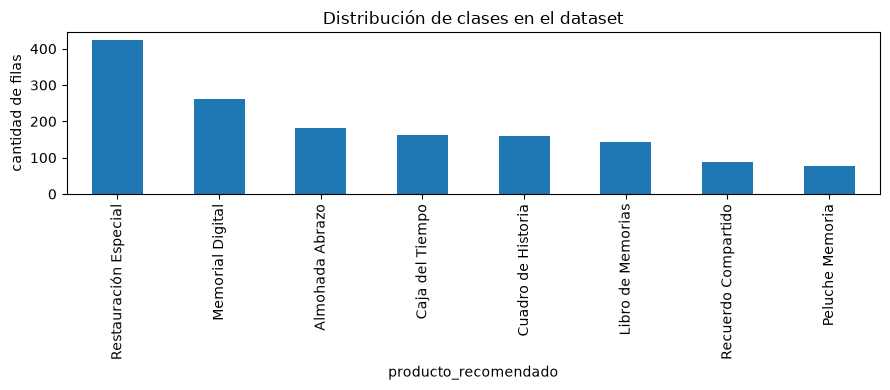

In [3]:
df["producto_recomendado"].value_counts().plot(
    kind="bar", figsize=(9, 4), title="Distribución de clases en el dataset"
)
plt.ylabel("cantidad de filas")
plt.tight_layout()
plt.show()

## 3. Entrenamiento

Se separa 80% entrenamiento / 20% prueba (estratificado, para mantener la
proporción de cada clase en ambos conjuntos). El pipeline codifica las
variables categóricas con *one-hot encoding* y deja pasar las numéricas
(`presupuesto`, `cantidad`) tal cual — el árbol de decisión es invariante a
la escala.

In [4]:
from sklearn.model_selection import train_test_split

X = df[COLUMNAS_ENTRADA]
y = df["producto_recomendado"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Entrenamiento: {len(X_train)} filas — Prueba: {len(X_test)} filas")

pipeline = construir_pipeline(max_depth=8, random_state=42)
pipeline.fit(X_train, y_train)
print("Modelo entrenado.")

Entrenamiento: 1200 filas — Prueba: 300 filas
Modelo entrenado.


## 4. Evaluación

Métricas exigidas por el enunciado: *accuracy, precision, recall, F1 y
matriz de confusión*.

In [5]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

y_pred = pipeline.predict(X_test)

print(f"Accuracy:           {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision (macro):  {precision_score(y_test, y_pred, average='macro', zero_division=0):.3f}")
print(f"Recall (macro):     {recall_score(y_test, y_pred, average='macro', zero_division=0):.3f}")
print(f"F1 (macro):         {f1_score(y_test, y_pred, average='macro', zero_division=0):.3f}")
print()
print(classification_report(y_test, y_pred, labels=CLASES, zero_division=0))

Accuracy:           0.813
Precision (macro):  0.835
Recall (macro):     0.784
F1 (macro):         0.803

                       precision    recall  f1-score   support

      Peluche Memoria       1.00      0.87      0.93        15
      Almohada Abrazo       0.90      0.78      0.84        36
   Cuadro de Historia       0.74      0.78      0.76        32
      Caja del Tiempo       0.86      0.59      0.70        32
    Libro de Memorias       0.73      0.83      0.77        29
Restauración Especial       0.77      0.93      0.84        85
  Recuerdo Compartido       0.80      0.67      0.73        18
     Memorial Digital       0.88      0.83      0.85        53

             accuracy                           0.81       300
            macro avg       0.84      0.78      0.80       300
         weighted avg       0.82      0.81      0.81       300



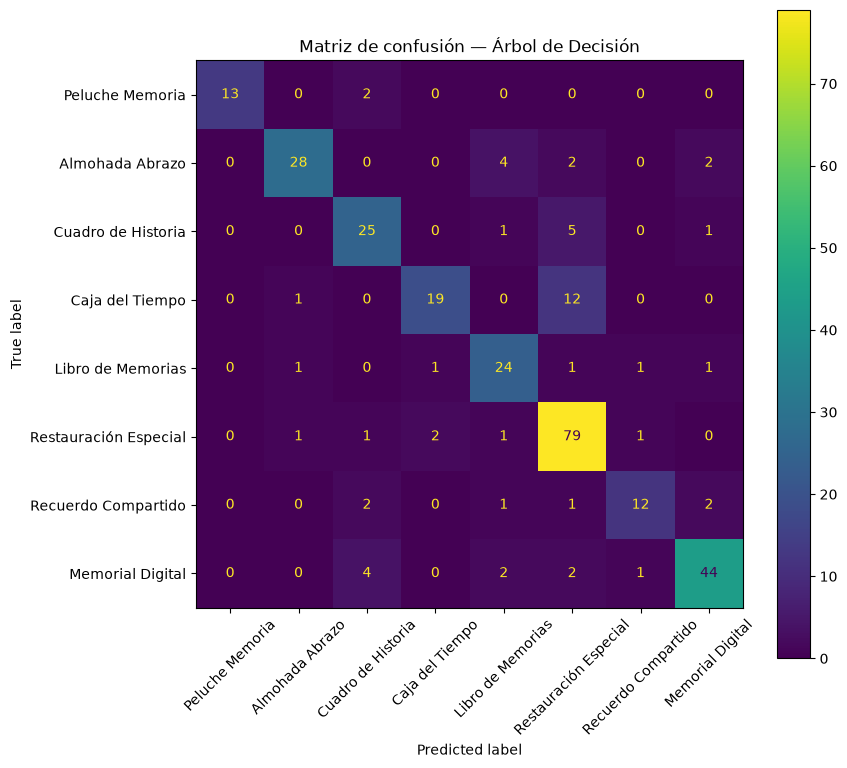

In [6]:
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, labels=CLASES, xticks_rotation=45, ax=ax
)
plt.title("Matriz de confusión — Árbol de Decisión")
plt.tight_layout()
plt.savefig("matriz_confusion.png", dpi=150)
plt.show()

## 5. Visualización del árbol

Se muestran solo los primeros 3 niveles — el árbol completo (`max_depth=8`)
tiene demasiados nodos para leerse en una imagen.

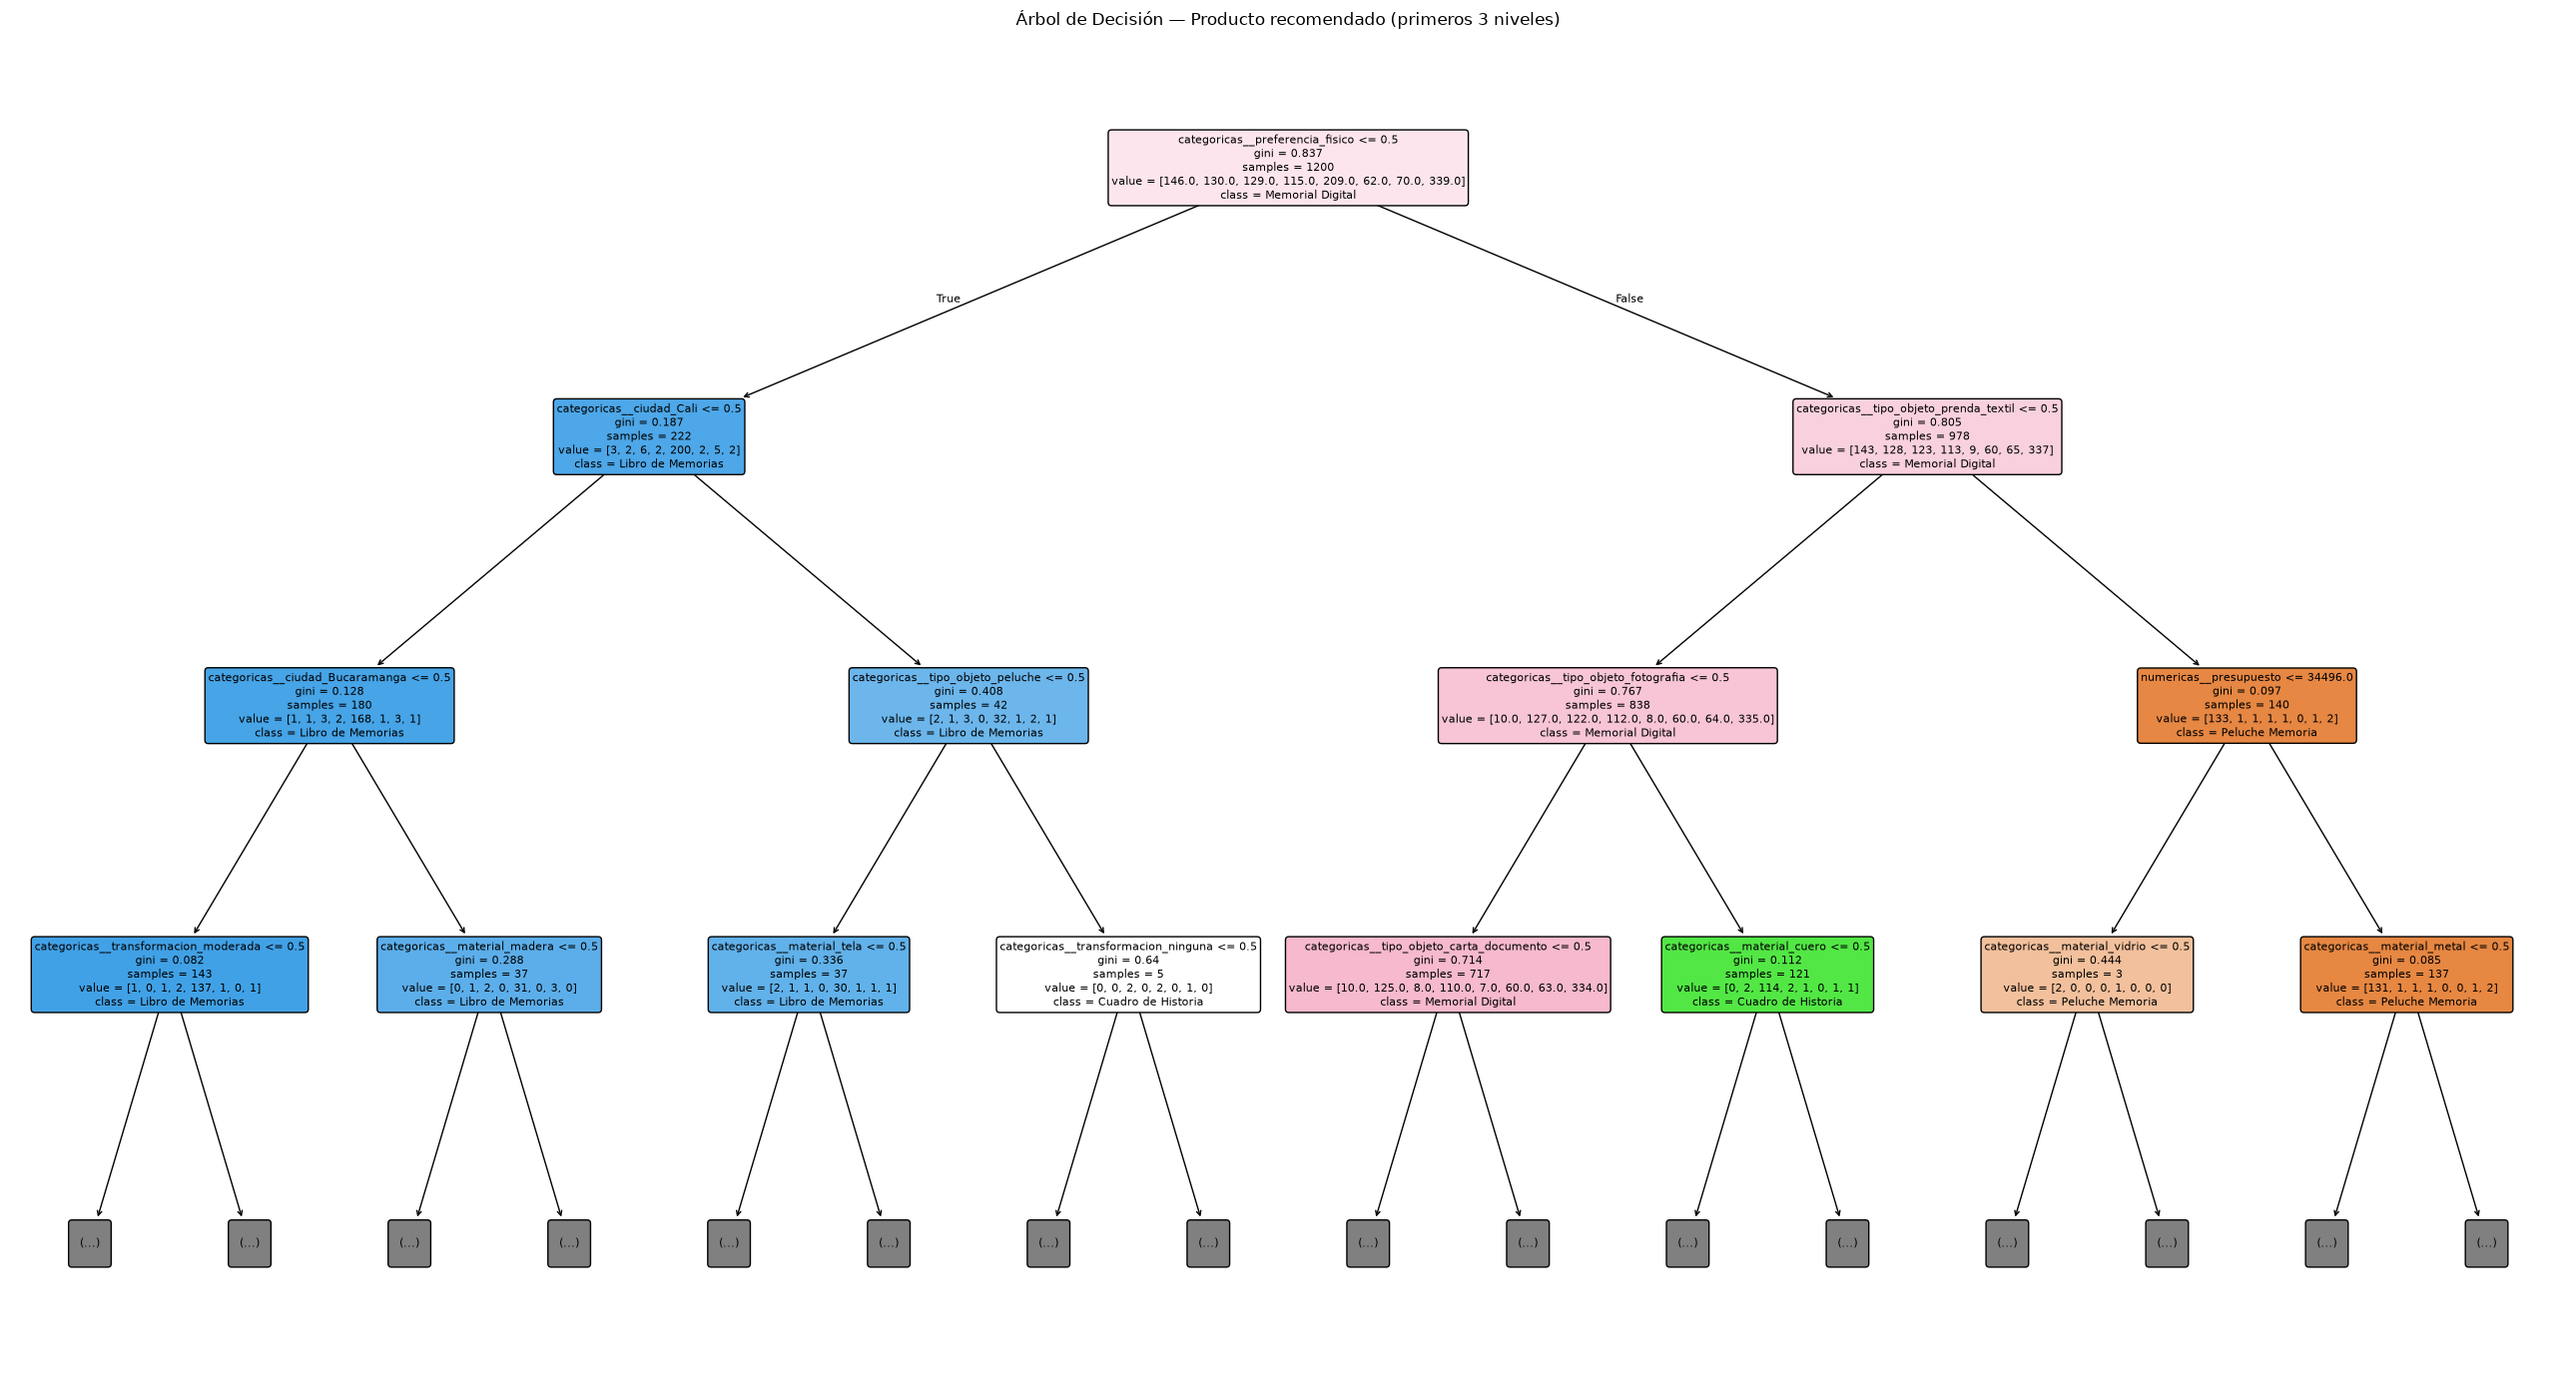

In [7]:
from sklearn.tree import plot_tree

nombres_features = pipeline.named_steps["preprocesador"].get_feature_names_out()

fig, ax = plt.subplots(figsize=(26, 14))
plot_tree(
    pipeline.named_steps["modelo"],
    feature_names=nombres_features,
    class_names=CLASES,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
    ax=ax,
)
plt.title("Árbol de Decisión — Producto recomendado (primeros 3 niveles)")
plt.tight_layout()
plt.savefig("arbol_decision.png", dpi=150)
plt.show()

## 6. Comparación con otros algoritmos

El enunciado pide el árbol de decisión como algoritmo base, con
"comparación opcional frente a Random Forest o KNN". Random Forest
promedia muchos árboles (reduce varianza); KNN clasifica por cercanía a
los vecinos más similares, así que necesita las variables numéricas
**escaladas** (`presupuesto` está en decenas de miles, `cantidad` entre 1
y 5 — sin escalar, `presupuesto` domina por completo la distancia).

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


def pipeline_con(modelo):
    pre = ColumnTransformer(
        transformers=[
            ("categoricas", OneHotEncoder(handle_unknown="ignore"), COLUMNAS_CATEGORICAS),
            ("numericas", StandardScaler(), COLUMNAS_NUMERICAS),
        ]
    )
    return Pipeline(steps=[("preprocesador", pre), ("modelo", modelo)])


resultados = []
for nombre, modelo in [
    ("Árbol de Decisión", pipeline.named_steps["modelo"]),
    ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42)),
    ("KNN (k=7)", KNeighborsClassifier(n_neighbors=7)),
]:
    if nombre == "Árbol de Decisión":
        y_p = y_pred  # ya entrenado arriba, mismo preprocesador
    else:
        pp = pipeline_con(modelo)
        pp.fit(X_train, y_train)
        y_p = pp.predict(X_test)
    resultados.append({
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_p),
        "precision_macro": precision_score(y_test, y_p, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_p, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_p, average="macro", zero_division=0),
    })

pd.DataFrame(resultados).set_index("modelo").round(3)

,accuracy,precision_macro,recall_macro,f1_macro
modelo,,,,
Árbol de Decisión,0.813,0.835,0.784,0.803
Random Forest,0.863,0.886,0.830,0.851
KNN (k=7),0.667,0.684,0.598,0.624


**Lectura del resultado:** los modelos basados en árboles (Árbol de
Decisión, Random Forest) superan a KNN en este problema — tiene sentido,
porque casi todas las variables de entrada son categóricas (con
codificación one-hot de alta dimensión), un escenario donde los árboles
particionan el espacio de forma mucho más natural que una métrica de
distancia entre vecinos. Random Forest mejora sobre el árbol individual al
promediar muchos árboles entrenados con submuestras distintas (reduce el
sobreajuste de un solo árbol), a costa de perder la interpretabilidad
visual directa que sí tiene el árbol de decisión.

## 7. Guardar el artefacto entrenado

Se guarda con `joblib` (incluye el `Pipeline` completo: preprocesamiento +
modelo, para que la API de producción no tenga que reimplementar la
codificación de variables).

In [9]:
import joblib

joblib.dump(pipeline, "modelo_recomendacion.joblib")
print("Guardado: modelo_recomendacion.joblib")

Guardado: modelo_recomendacion.joblib


## 8. Prueba manual del modelo entrenado

Un ejemplo de inferencia con datos nuevos (no vistos en entrenamiento),
igual que lo haría la API real.

In [10]:
ejemplo = pd.DataFrame([{
    "tipo_objeto": "peluche",
    "material": "peluche_sintetico",
    "estado": "bueno",
    "uso_deseado": "conservar",
    "presupuesto": 70000,
    "cantidad": 1,
    "transformacion": "leve",
    "ciudad": "Bogota",
    "preferencia": "fisico",
}])

prediccion = pipeline.predict(ejemplo)[0]
probabilidades = pipeline.predict_proba(ejemplo)[0]

print("Producto recomendado:", prediccion)
print()
for clase, prob in sorted(zip(pipeline.classes_, probabilidades), key=lambda x: -x[1]):
    print(f"  {clase:25s} {prob:.1%}")

Producto recomendado: Peluche Memoria

  Peluche Memoria           94.5%
  Almohada Abrazo           1.8%
  Cuadro de Historia        1.8%
  Memorial Digital          1.8%
  Caja del Tiempo           0.0%
  Libro de Memorias         0.0%
  Recuerdo Compartido       0.0%
  Restauración Especial     0.0%


## 9. Integración con el sistema real

Este mismo `model_recomendacion.py` y el artefacto `modelo_recomendacion.joblib`
los usa `Backend/api/apps/ml/views.py` para exponer
`POST /api/v1/ml/recomendar-producto`, que el flujo de n8n del **agente de
Recomendación** (`agente-recomendacion.json`) consulta como una señal
adicional — real, entrenada — junto a la propuesta del LLM, no como un
ejercicio aislado.

**Limitación conocida y documentada:** de las 9 variables de entrada, hoy
Reviive solo captura de forma real `tipo_objeto`, `material`, `estado` y
`transformacion` (los campos de `ObjetoMemoria`) más `cantidad` (número de
objetos del recuerdo). `uso_deseado`, `presupuesto`, `ciudad` y
`preferencia` todavía no se capturan en el flujo de registro de un
recuerdo, así que la integración usa un valor neutro documentado para esos
campos (ver `fila_desde_objeto_memoria` en `model_recomendacion.py`) en vez
de inventarlos a partir de datos que no existen.